In [95]:
#Test pour les diagrammes alluviaux

import plotly.graph_objects as go
from ipywidgets import widgets
import pandas as pd
import numpy as np
from collections import defaultdict

File_name="Extraction flux patients.xlsx"

diag = pd.read_excel(File_name, sheet_name="Secto 69", header =0, usecols = "A:D", nrows=263, dtype={1:str})

sectorisation_communes_rhone=defaultdict()

for row in diag.itertuples(index=False):
    sectorisation_communes_rhone[row[1]]=[row[3],row[0]]


set_secteurs = {a for _, [a, b] in sectorisation_communes_rhone.items()}
set_secteurs.add("externe")
set_secteurs=list(set_secteurs)
set_secteurs.sort()

In [99]:
nom_feuille="69 2024"
Rhone16 = pd.read_excel(File_name, sheet_name=nom_feuille, header =0, usecols = "A:I", nrows=55000, dtype={5:str, 6:str, 7:str, 8:int})

Trajet_0_1=defaultdict(int)
Trajet_1_2=defaultdict(int)
ext = "externe"

for row in Rhone16.itertuples(index=False):

    com_pat=row[5]
    com_presc=row[6]
    com_off=row[7]
    effectif=row[8]

    secteur_0 = sectorisation_communes_rhone.get(com_pat, [ext])[0]
    secteur_1 = sectorisation_communes_rhone.get(com_presc, [ext])[0]
    
    nom_trajet_0_1 = secteur_0 +" "+ secteur_1
    Trajet_0_1[nom_trajet_0_1] += effectif

    secteur_2 = sectorisation_communes_rhone.get(com_off, [ext])[0]
    
    nom_trajet_1_2 = secteur_1 +" "+ secteur_2
    Trajet_1_2[nom_trajet_1_2] += effectif


In [100]:
def generer_liste_modifiee(liste_mots, repetitions=3):
    nouvelle_liste = []
    text=["0","1","2"]
    for i in range(repetitions):
        for mot in liste_mots:
                nouvelle_liste.append(f"{mot}")
    return nouvelle_liste

# Exemple d'utilisation
liste_originale=list(set_secteurs)
labels = generer_liste_modifiee(liste_originale)

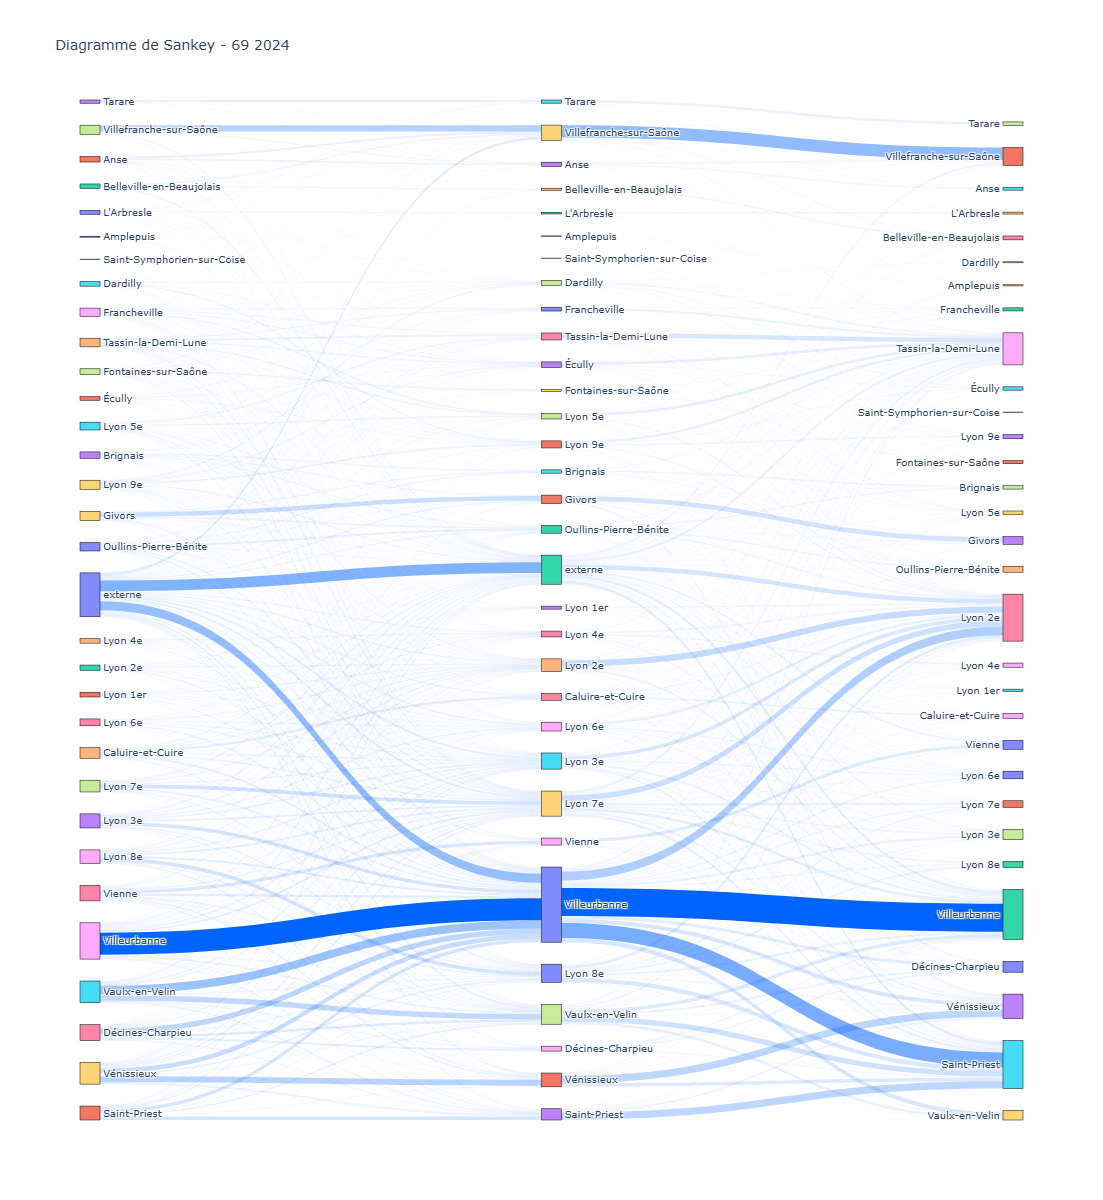

In [122]:
source = []
target = []
values = []
colors = []
intra=(0,100,255)
inter=(255,100,0)
extra=(0,0,0)

for clé, objet in Trajet_0_1.items() :

    paire_secteurs = [clé.split(" ", 2)[0] + " " + clé.split(" ", 2)[1], clé.split(" ", 2)[2]] if clé.startswith("Lyon ") or clé.startswith("La ") or clé.startswith("Le ") or clé.startswith("Les ")  else clé.split(" ", 1)

    source.append(set_secteurs.index(paire_secteurs[0]))
    target.append(set_secteurs.index(paire_secteurs[1])+len(set_secteurs))
    values.append(objet)

for clé, objet in Trajet_1_2.items() :
    paire_secteurs = [clé.split(" ", 2)[0] + " " + clé.split(" ", 2)[1], clé.split(" ", 2)[2]] if clé.startswith("Lyon ") or clé.startswith("La ") or clé.startswith("Le ") or clé.startswith("Les ")  else clé.split(" ", 1)

    source.append(set_secteurs.index(paire_secteurs[0])+len(set_secteurs))
    target.append(set_secteurs.index(paire_secteurs[1])+2*len(set_secteurs))
    values.append(objet)

#Fabrique le diagramme de Sankey
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=30,  # espacement entre les noeuds
        thickness=20,  # épaisseur des noeuds
        line=dict(color="black", width=0.5),
        label=labels,
    
        
    ),
    link=dict(
        source=source,
        target=target,
        value=values,
        color=[f"rgba(0,100,255,{v / max(values[:len(Trajet_0_1)]) if i < len(Trajet_0_1) else v / max(values[len(Trajet_0_1):]):.2f})"
            for i, v in enumerate(values)]  # Exemple de couleur semi-transparente

    # color = [f"rgba({(source[i]*40)%255}, {(source[i]*80)%255}, {(source[i]*120)%255},{v / max(values[:len(Trajet_0_1)]) if i < len(Trajet_0_1) else v / max(values[len(Trajet_0_1):]):.2f})"
    #         for i, v in enumerate(values)]
    )
)])

# Add title and display the diagram
fig.update_layout(title_text=f"Diagramme de Sankey - {nom_feuille}", font_size=10, width=1000, height=1200)
fig.show()

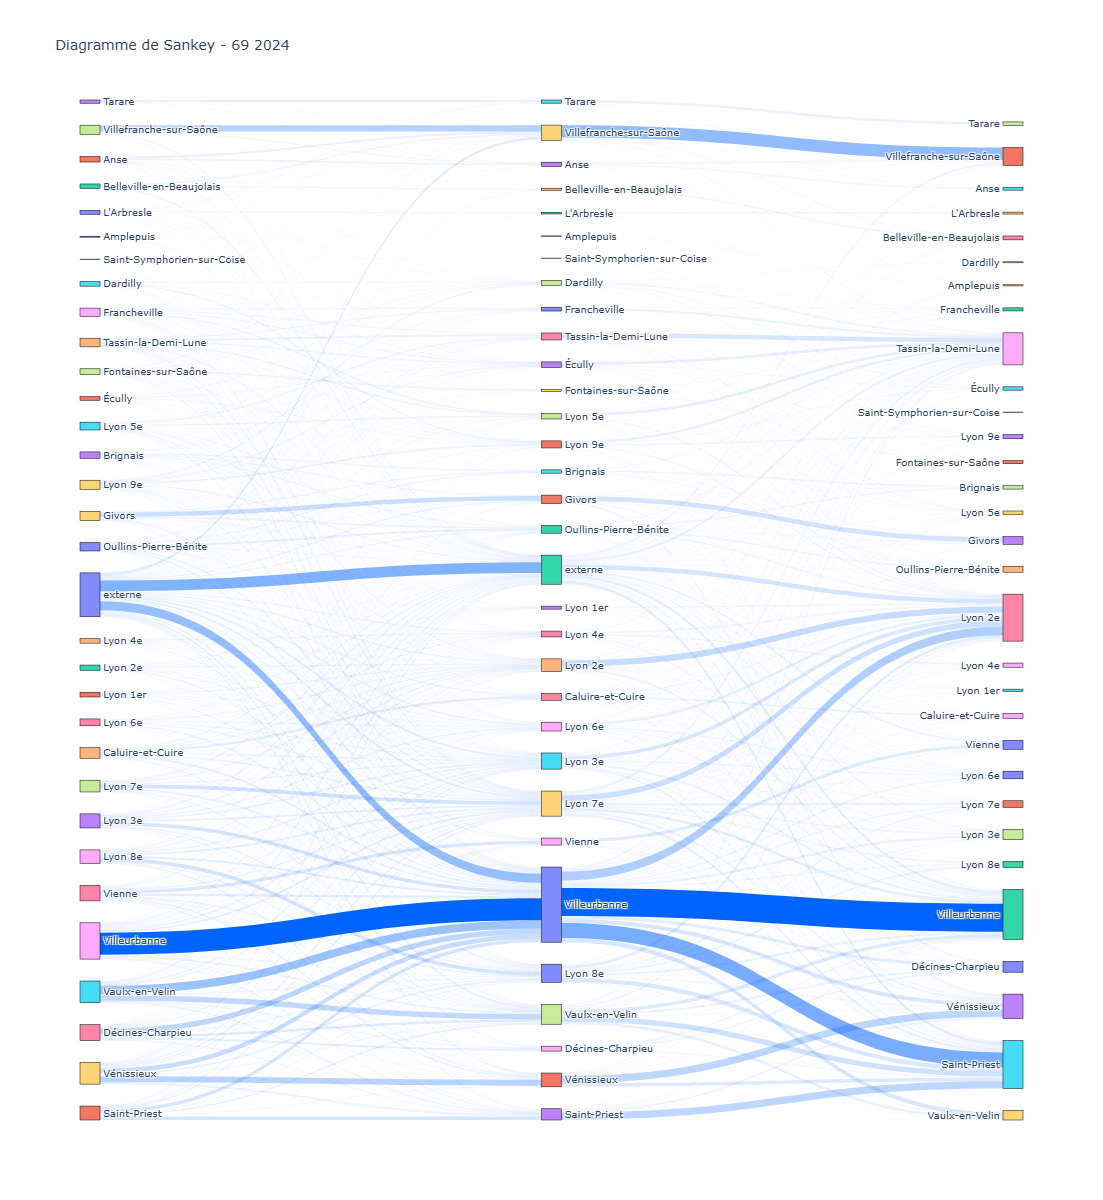

In [2]:
# --------------------------------------------
# Création de diagrammes Sankey
# Objectif : visualiser les flux de patients entre communes, prescripteurs et officines.
# --------------------------------------------

import plotly.graph_objects as go      # Pour construire le diagramme de Sankey
from ipywidgets import widgets         # (optionnel ici, utile si interaction Jupyter prévue)
import pandas as pd                    # Pour manipuler les données Excel
import numpy as np                     # Pour des calculs numériques si besoin
from collections import defaultdict    # Pour gérer les dictionnaires à valeurs par défaut

# -------------------------------------------- Chargement des données de sectorisation --------------------------------------------

File_name = "[nom_du_fichier].xlsx"

# Lecture du fichier Excel contenant les correspondances communes-secteurs
# - sheet_name : nom de la feuille à lire
# - usecols : colonnes pertinentes
# - dtype : forcer certaines colonnes en texte pour éviter les erreurs de type
diag = pd.read_excel(File_name, sheet_name="[nom_de_la_feuille]", header=0, usecols="[colonnes]", nrows=["nombre_de_lignes"], dtype={1: str})

# Dictionnaire : {nom_commune: [secteur, code_postal]}
sectorisation_communes_rhone = defaultdict()

for row in diag.itertuples(index=False):
    # row[1] = commune, row[3] = secteur, row[0] = code postal (par exemple)
    sectorisation_communes_rhone[row[1]] = [row[3], row[0]]

# -------------------------------------------- Préparation de la liste des secteurs --------------------------------------------

# On crée un ensemble des secteurs distincts
set_secteurs = {a for _, [a, _] in sectorisation_communes_rhone.items()}
set_secteurs.add("externe")  # pour les communes non reconnues
set_secteurs = sorted(list(set_secteurs))  # tri alphabétique pour un affichage stable

# -------------------------------------------- Lecture des données de flux patients --------------------------------------------

nom_feuille = "[nom_de_la_feuille]"

Fichier_trajets = pd.read_excel(File_name, sheet_name=nom_feuille, header=0, usecols="[colonnes]", nrows=["nombre_de_lignes"], dtype={5: str, 6: str, 7: str, 8: int})

# Dictionnaires pour accumuler les flux entre étapes
Trajet_0_1 = defaultdict(int)  # patient → prescripteur
Trajet_1_2 = defaultdict(int)  # prescripteur → officine
ext = "externe"  # libellé par défaut si commune inconnue

# -------------------------------------------- Construction des flux entre secteurs --------------------------------------------

for row in Fichier_trajets.itertuples(index=False):
    com_pat, com_presc, com_off, effectif = row[5], row[6], row[7], row[8]

    # Étape 0 → 1 : patient → prescripteur
    secteur_0 = sectorisation_communes_rhone.get(com_pat, [ext])[0]
    secteur_1 = sectorisation_communes_rhone.get(com_presc, [ext])[0]
    Trajet_0_1[f"{secteur_0} {secteur_1}"] += effectif

    # Étape 1 → 2 : prescripteur → officine
    secteur_2 = sectorisation_communes_rhone.get(com_off, [ext])[0]
    Trajet_1_2[f"{secteur_1} {secteur_2}"] += effectif

# -------------------------------------------- Création de la liste complète des labels (3 répétitions pour 3 étapes) --------------------------------------------

def generer_liste_modifiee(liste_mots, repetitions=3):
    """
    Répète la liste de labels pour les différentes étapes du Sankey.
    Exemple : ['A', 'B'] → ['A', 'B', 'A', 'B', 'A', 'B']
    3 étapes donc 3 répétitions de tous les secteurs. Source intiale > cible intermétidaire = source intermédiaire > cible finale
    """
    nouvelle_liste = []
    for _ in range(repetitions):
        nouvelle_liste.extend(liste_mots)
    return nouvelle_liste

liste_originale = list(set_secteurs)
labels = generer_liste_modifiee(liste_originale)

# -------------------------------------------- Construction des liens du diagramme (source → target) --------------------------------------------

source, target, values = [], [], []

def extraire_paire_secteurs(cle):
    """
    Sépare proprement une clé 'SecteurA SecteurB'
    en prenant en compte les noms à plusieurs mots (Lyon, La, Le, Les...).
    """
    prefixes = ("Lyon ", "La ", "Le ", "Les ")
    if cle.startswith(prefixes):
        # On découpe à 2 espaces maximum pour garder les bons noms
        return [cle.split(" ", 2)[0] + " " + cle.split(" ", 2)[1], cle.split(" ", 2)[2]]
    else:
        return cle.split(" ", 1)

# Étape 0 → 1
for cle, effectif in Trajet_0_1.items():
    secteur_a, secteur_b = extraire_paire_secteurs(cle)
    source.append(set_secteurs.index(secteur_a))
    target.append(set_secteurs.index(secteur_b) + len(set_secteurs))
    values.append(effectif)

# Étape 1 → 2
for cle, effectif in Trajet_1_2.items():
    secteur_a, secteur_b = extraire_paire_secteurs(cle)
    source.append(set_secteurs.index(secteur_a) + len(set_secteurs))
    target.append(set_secteurs.index(secteur_b) + 2 * len(set_secteurs))
    values.append(effectif)

# -------------------------------------------- Création et affichage du diagramme Sankey --------------------------------------------

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=30,               # espacement entre les noeuds
        thickness=20,         # épaisseur des noeuds
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values,
        # Dégradé de couleur selon l'intensité du flux
        color=[
            f"rgba(0,100,255,{v / max(values[:len(Trajet_0_1)]) if i < len(Trajet_0_1) else v / max(values[len(Trajet_0_1):]):.2f})"
            for i, v in enumerate(values)
        ]
    )
)])

# Spécification de certains aspects visuels du diagramme
fig.update_layout(
    title_text=f"Diagramme de Sankey - {nom_feuille}",
    font_size=10,               # police d'écriture
    width=1000,                 # épaisseur de la zone d'affichage
    height=1200                 # hauteur de la zone d'affichage
)
fig.show()                      # Affichage du diagramme dans la fenêtre de visualisation de l'environnement de développement intéractif